# Telco Customer Churn — Analysis & Prediction

**Author:** Jahanvi Kashyap  
**Dataset:** IBM Telco Customer Churn (Kaggle, ~7K rows)  
**Goal:** Identify *who* churns, *why*, and *what to do about it*.

---

## Notebook map
1. Business Framing
2. Data Loading & Inspection
3. Data Cleaning  ← *you are here*
4. Exploratory Data Analysis *(coming next)*
5. Cohort & Segmentation
6. Feature Engineering
7. Modeling (Logistic Regression + Random Forest)
8. Model Evaluation
9. Feature Importance + SHAP
10. Business Recommendations

## 1. Business Framing

### Why churn matters
Telecom companies live and die by **monthly recurring revenue (MRR)**. Every customer who cancels is a hole in next month's revenue — and acquiring a replacement is far more expensive.

Industry benchmarks (Harvard Business Review, Bain & Co.):
- Acquiring a new customer costs **5–25× more** than retaining an existing one.
- A **5% increase in retention** can lift profits by **25–95%**.
- Churned customers also stop generating word-of-mouth referrals — a hidden second cost.

### The economic model in one line
$$
\text{Net Saved Revenue} = (\text{customers retained}) \times (\text{ARPU}) \times (\text{remaining lifetime months}) \;-\; \text{retention offer cost}
$$

Where **ARPU** = Average Revenue Per User (here, `MonthlyCharges`).

### Why this matters for the model design
Two error types — and they are **not equally costly**:

| Error | What happens | Cost |
|---|---|---|
| **False Negative** (model says "won't churn" but does) | Customer leaves silently | Lost MRR forever — **HIGH cost** |
| **False Positive** (model says "will churn" but doesn't) | Loyal customer gets a discount they didn't need | Small wasted offer — **LOW cost** |

→ This asymmetry tells us to **optimize Recall**, not Accuracy. Better to over-flag than miss a leaver.

### Questions this analysis will answer
1. What is the overall churn rate, and how does it compare to industry norms (~22–25% telecom)?
2. Which customer segments churn most? (contract type, tenure, services bought)
3. Which features are the strongest predictors?
4. Can we predict churn well enough to act on it (target Recall ≥ 0.75)?
5. What concrete retention plays should the business run, and what is the expected ROI?

## 2. Data Loading & Inspection

**Goal of this section:** before any analysis, *look* at the data. Answer:
- How big is it?
- What columns and types?
- Any obvious mess (wrong dtype, missing values, duplicates)?
- What is the class balance of the target?

Skipping this step is the #1 reason analyses go wrong later.

In [1]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
# pandas      -> tables / dataframes (the analyst's spreadsheet)
# numpy       -> numeric arrays, used under the hood by pandas
# matplotlib  -> base plotting library
# seaborn     -> prettier statistical plots, built on matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display + style settings so output looks clean in the notebook
pd.set_option('display.max_columns', None)   # show all columns, never truncate
pd.set_option('display.width', 140)          # wider console output
sns.set_style('whitegrid')                   # subtle grid lines on plots
plt.rcParams['figure.figsize'] = (9, 5)      # default plot size

# Reproducibility: fix random seed so results are identical on every run
RANDOM_STATE = 42

In [2]:
# ---------------------------------------------------------------
# Load the raw CSV
# ---------------------------------------------------------------
DATA_PATH = '../data/raw/telco_churn.csv'
df = pd.read_csv(DATA_PATH)
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

Rows: 7,043   Columns: 21


In [3]:
# First 5 rows — a visual sniff test.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**What to look for in `.head()`:**
- `customerID` — unique key, will be dropped before modeling.
- `SeniorCitizen` — already 0/1.
- Service columns use *three* states: `Yes`, `No`, `No internet service` / `No phone service`. We will collapse those during cleaning.
- `Churn` is `Yes/No` — our target.

In [4]:
# Column dtypes + non-null counts. Watch for object cols that should be numeric.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Red flag spotted:** `TotalCharges` is `object` (string) but is a money amount. The famous Telco-dataset gotcha: 11 customers with `tenure=0` have a literal space `" "` instead of a number. We fix this in Section 3.

In [5]:
# Numeric summary.
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Categorical summary. In pandas 3, exclude='number' is future-proof.
df.describe(exclude='number')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
# Hunt hidden missing values.
blank_total_charges = (df['TotalCharges'].str.strip() == '').sum()
print(f'Rows with blank TotalCharges: {blank_total_charges}')
df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Insight:** all 11 rows have `tenure = 0` → brand-new, never billed. None churned. We will set their `TotalCharges = 0` in Section 3.

In [8]:
# Standard null check.
df.isnull().sum().sort_values(ascending=False).head(5)

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

In [9]:
print(f'Duplicate rows:        {df.duplicated().sum()}')
print(f'Duplicate customerIDs: {df["customerID"].duplicated().sum()}')

Duplicate rows:        0
Duplicate customerIDs: 0


In [10]:
# Target balance — drives modeling decisions later.
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': churn_counts, 'percent': churn_rate.round(2)})
print(summary)
print(f"\nOverall churn rate: {churn_rate['Yes']:.2f}%")

       count  percent
Churn                
No      5174    73.46
Yes     1869    26.54

Overall churn rate: 26.54%


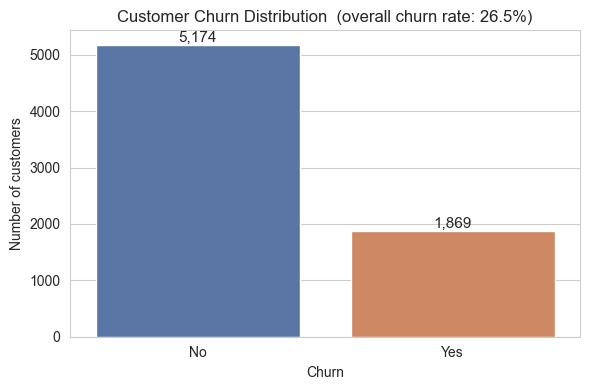

In [11]:
# Class-balance chart — first portfolio artifact.
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], hue='Churn',
              palette=['#4C72B0', '#DD8452'], legend=False, ax=ax)
ax.set_title(f'Customer Churn Distribution  (overall churn rate: {churn_rate["Yes"]:.1f}%)')
ax.set_ylabel('Number of customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 2 — Takeaways

1. **Size:** 7,043 customers × 21 columns.
2. **Target:** ~26.5% churn rate. Consistent with telecom industry norms.
3. **Class imbalance:** moderate (~3:1). Use stratified train/test split, watch Recall.
4. **Issues to fix:** `TotalCharges` is text with 11 blanks; service cols have a redundant 3rd state.
5. **No duplicates.** `customerID` is a clean unique key.

## 3. Data Cleaning

Turn the messy raw `df` into a tidy `df_clean` that is safe to analyze and model.

### Plan (each step has a *why*)
1. **Work on a copy** — never mutate raw data. If something goes wrong, we re-run from `df`, not re-download the CSV.
2. **Fix `TotalCharges`** — convert from string to float, replace 11 blanks with `0` (logically correct: tenure-0 customers haven't been billed).
3. **Collapse "No internet service" / "No phone service"** — semantically identical to `No`. Three categories where two would do = noise.
4. **Encode binary Yes/No columns** to `0/1` — models can't read text. Multi-class columns are kept as text for now; we one-hot encode them at modeling time so EDA charts stay readable.
5. **Map the target `Churn`** to `0/1`.
6. **Save** the cleaned dataframe to `data/processed/`.

**Cleaning vs feature engineering:** cleaning fixes errors and standardizes format. Feature engineering creates *new* signal (tenure buckets, service counts). Different jobs, different sections.

In [12]:
# ---------------------------------------------------------------
# Step 1: Work on a copy. NEVER mutate raw data.
# ---------------------------------------------------------------
# .copy() is critical — without it, df_clean would be a *view* of df,
# meaning changes to one would silently change the other. Classic pandas footgun.
df_clean = df.copy()
print(f'df_clean shape: {df_clean.shape}')

df_clean shape: (7043, 21)


### 3.1 Fix `TotalCharges`

Two things to do:
1. Convert string → numeric. `pd.to_numeric(..., errors='coerce')` turns any unparseable value (the 11 blanks) into `NaN` instead of crashing.
2. Decide what to do with the 11 NaNs. They all have `tenure=0`, so logically `TotalCharges = 0` (paid nothing yet). Filling with `0` keeps the rows and preserves the relationship `TotalCharges ≈ tenure × MonthlyCharges`.

**Alternative considered:** drop the 11 rows. We chose to fill with 0 — keeps every customer, defensible logic.

In [13]:
# Convert string -> float. Anything non-numeric becomes NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# How many NaN now? Should be 11.
n_missing = df_clean['TotalCharges'].isna().sum()
print(f'NaN count after coerce: {n_missing}')

# Replace NaN with 0.
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# Verify.
print(f'New dtype: {df_clean["TotalCharges"].dtype}')
print(f'NaN count after fillna: {df_clean["TotalCharges"].isna().sum()}')

# Sanity check the formerly-blank rows.
df_clean[df_clean['tenure'] == 0][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

NaN count after coerce: 11
New dtype: float64
NaN count after fillna: 0


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0


### 3.2 Collapse redundant categories

Six service columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) use **three** states:
- `Yes` → has the service
- `No` → has internet but didn't buy this add-on
- `No internet service` → can't have it (no internet plan at all)

From a churn-modeling standpoint, the last two are the same: "customer doesn't have this service." The fact that they have no internet at all is already captured by `InternetService`. Three states triples one-hot dimensions without adding signal — pure noise.

Same logic for `MultipleLines`: `No phone service` → `No`.

In [14]:
# Replace the redundant strings everywhere they appear.
df_clean = df_clean.replace({
    'No internet service': 'No',
    'No phone service':    'No',
})

# Verify.
print('OnlineSecurity values:', df_clean['OnlineSecurity'].unique())
print('MultipleLines values: ', df_clean['MultipleLines'].unique())

OnlineSecurity values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines values:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str


### 3.3 Encode binary Yes/No columns to 0/1

Models need numbers. `Yes → 1, No → 0` does two things:
- Makes columns model-ready.
- The 1/0 has a *meaning* — `1 = has-the-thing`, so the sign of a model coefficient becomes interpretable (positive coef = more likely to churn).

We do **not** one-hot encode multi-category columns (`Contract`, `InternetService`, `PaymentMethod`, `gender`) here. Those are easier to read in EDA charts as text — we'll one-hot only at model fit time.

In [15]:
# Columns whose values are only Yes/No after the previous step.
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
]

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0}).astype('int8')

# Map the target too — Yes (churned) = 1.
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0}).astype('int8')

df_clean[binary_cols + ['Churn']].dtypes

Partner             int8
Dependents          int8
PhoneService        int8
MultipleLines       int8
OnlineSecurity      int8
OnlineBackup        int8
DeviceProtection    int8
TechSupport         int8
StreamingTV         int8
StreamingMovies     int8
PaperlessBilling    int8
Churn               int8
dtype: object

In [16]:
# Final sanity check on the cleaned dataframe.
print('Shape:', df_clean.shape)
print('\nDtypes summary:')
print(df_clean.dtypes.value_counts())
print('\nNulls anywhere?', df_clean.isnull().sum().sum())
print('\nChurn distribution (1=churned, 0=stayed):')
print(df_clean['Churn'].value_counts(normalize=True).round(3))
df_clean.head()

Shape: (7043, 21)

Dtypes summary:
int8       12
str         5
int64       2
float64     2
Name: count, dtype: int64

Nulls anywhere? 0

Churn distribution (1=churned, 0=stayed):
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


### 3.4 Save the cleaned dataframe

Saved to `data/processed/` so future sections (and re-runs) start from clean data without re-running cleaning. This also gives us an audit trail: "this is the data the model saw."

In [17]:
OUT_PATH = '../data/processed/telco_churn_clean.csv'
df_clean.to_csv(OUT_PATH, index=False)
print(f'Saved cleaned dataframe -> {OUT_PATH}')

Saved cleaned dataframe -> ../data/processed/telco_churn_clean.csv


### Section 3 — Takeaways

1. `TotalCharges` is now `float64`, with 0 imputed for the 11 brand-new customers.
2. Service columns now have only `Yes`/`No`.
3. All binary columns and the target `Churn` are now `0/1` integers.
4. Multi-class columns (`Contract`, `InternetService`, `PaymentMethod`, `gender`) intentionally left as text for readable EDA charts.
5. Cleaned dataframe saved to `data/processed/telco_churn_clean.csv`.

**Next:** Section 4 — Exploratory Data Analysis. One chart + one written insight per major feature, then identify the top 5 churn drivers visually before any modeling.